# 02 — Membangun Split yang Sah

Notebook 01 menemukan bahwa split resmi dataset **bocor sempurna**: seluruh 91
tumpukan muncul di sisi latih, sehingga 100% tumpukan di valid dan test sudah
pernah dilihat model. Metrik apa pun dari split itu mengukur hafalan, bukan
generalisasi.

Notebook ini menyelesaikan empat masalah sekaligus:

| # | Masalah | Cara diselesaikan |
|---|---|---|
| 1 | Kebocoran antar-split | Pembagian pada tingkat **tumpukan**, bukan gambar |
| 2 | Kelompok kelas tunggal | **Stratifikasi menurut kelompok** tumpukan |
| 3 | Satu tumpukan = 421 frame | Pembagian sadar **bobot frame**, plus opsi pembatasan |
| 4 | Risiko jalan pintas | Menandai tumpukan **murni vs campuran**, dipastikan keduanya ada di tiap sisi |

Keluaran akhir: manifes split yang dipakai seluruh eksperimen berikutnya.

In [1]:
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))

import vizstyle as vs
import dataio as dio
vs.apply_style()

ROOT = Path.cwd().parents[1]
DATA = ROOT / "data" / "raw" / "piles-kalsel"
OUT = ROOT / "data" / "interim"
OUT.mkdir(parents=True, exist_ok=True)

imgs, boxes = dio.load_index(DATA)
prof = dio.pile_profile(imgs, boxes)

print(f"{len(imgs):,} gambar | {len(boxes):,} kotak | {len(prof)} tumpukan")

4,160 gambar | 14,558 kotak | 91 tumpukan


## 1. Seberapa parah kebocorannya?

Menghitung tumpukan yang beririsan sudah cukup untuk membuktikan ada kebocoran.
Tetapi yang lebih menjelaskan **seberapa parah** adalah pertanyaan berikut:

> Untuk setiap gambar di sisi uji, seberapa dekat frame terdekat dari tumpukan
> yang sama yang ada di sisi latih?

Kalau jaraknya sering 1, artinya sisi uji berisi frame yang praktis kembar
dengan frame di sisi latih — bukan sekadar "tumpukan yang sama", melainkan
"momen yang sama".

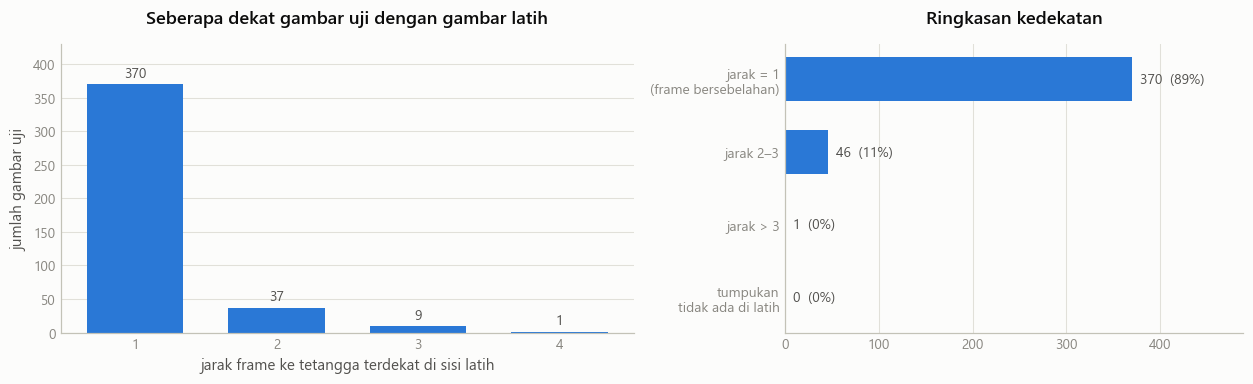

Median jarak frame terdekat : 1
Gambar uji dengan frame bersebelahan di latih : 370 / 417 (88.7%)


In [2]:
train_frames = (imgs[imgs.split_resmi == "train"]
                .groupby("pile")["frame"].apply(lambda s: np.sort(s.values)))

def jarak_terdekat(row):
    arr = train_frames.get(row["pile"])
    if arr is None or len(arr) == 0:
        return np.nan
    return int(np.min(np.abs(arr - row["frame"])))

test_imgs = imgs[imgs.split_resmi == "test"].copy()
test_imgs["jarak"] = test_imgs.apply(jarak_terdekat, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6),
                         gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
vc = test_imgs["jarak"].value_counts().sort_index()
vc = vc[vc.index <= 10]
b = ax.bar(vc.index.astype(int), vc.values, color=vs.PRIMARY, width=0.68)
vs.label_bars(ax, b, fmt="{:,.0f}")
ax.set_xlabel("jarak frame ke tetangga terdekat di sisi latih")
ax.set_ylabel("jumlah gambar uji")
ax.set_title("Seberapa dekat gambar uji dengan gambar latih")
ax.set_xticks(vc.index.astype(int))
ax.set_ylim(0, vc.max() * 1.16)

ax = axes[1]
kat = pd.Series({
    "jarak = 1\n(frame bersebelahan)": int((test_imgs.jarak == 1).sum()),
    "jarak 2–3": int(test_imgs.jarak.between(2, 3).sum()),
    "jarak > 3": int((test_imgs.jarak > 3).sum()),
    "tumpukan\ntidak ada di latih": int(test_imgs.jarak.isna().sum()),
})
b = ax.barh(range(len(kat)), kat.values, color=vs.PRIMARY, height=0.6)
ax.set_yticks(range(len(kat))); ax.set_yticklabels(kat.index, fontsize=9)
ax.invert_yaxis(); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
for i, v in enumerate(kat.values):
    ax.annotate(f"{v}  ({v/len(test_imgs)*100:.0f}%)", (v, i), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=9,
                color=vs.INK_SECONDARY)
ax.set_xlim(0, kat.max() * 1.32)
ax.set_title("Ringkasan kedekatan")

plt.tight_layout(); plt.show()

print(f"Median jarak frame terdekat : {test_imgs['jarak'].median():.0f}")
print(f"Gambar uji dengan frame bersebelahan di latih : "
      f"{(test_imgs.jarak <= 1).sum()} / {len(test_imgs)} "
      f"({(test_imgs.jarak <= 1).mean()*100:.1f}%)")

> Angka ini yang sebenarnya menjelaskan kenapa split resmi tidak bisa dipakai.
> Bukan sekadar "tumpukan yang sama muncul di dua sisi" — melainkan gambar uji
> berisi frame yang berjarak satu langkah dari gambar latih. Untuk model, itu
> praktis gambar yang sama.

## 2. Karakter tumpukan: murni vs campuran

Notebook 01 menemukan sebagian tumpukan direkam per kelas tunggal. Di sini
karakternya dikuantifikasi, karena ini menentukan dua hal: cara stratifikasi,
dan cara evaluasi nanti.

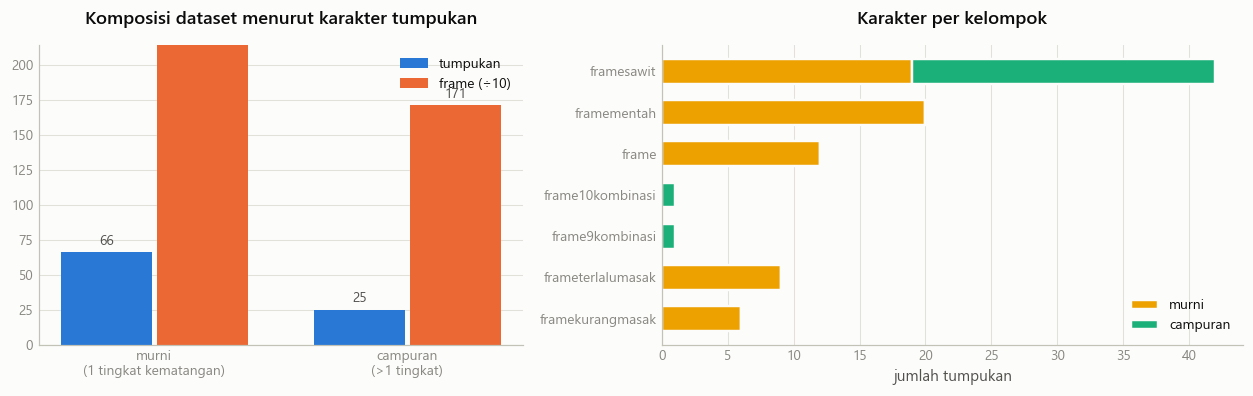

,tumpukan,frame,murni,frame_per_tumpukan
group,,,,
framesawit,42,1677,19,39.9
framementah,20,685,20,34.2
frame,12,465,12,38.8
frame10kombinasi,1,421,0,421.0
frame9kombinasi,1,362,0,362.0
frameterlalumasak,9,356,9,39.6
framekurangmasak,6,194,6,32.3


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.7),
                         gridspec_kw={"width_ratios": [1, 1.2]})

ax = axes[0]
n_murni = int(prof["murni"].sum()); n_camp = len(prof) - n_murni
f_murni = int(prof.loc[prof.murni, "n_frame"].sum())
f_camp = int(prof.loc[~prof.murni, "n_frame"].sum())
x = np.arange(2)
b1 = ax.bar(x - 0.19, [n_murni, n_camp], width=0.36,
            color=vs.CATEGORICAL[0], label="tumpukan")
b2 = ax.bar(x + 0.19, [f_murni/10, f_camp/10], width=0.36,
            color=vs.CATEGORICAL[1], label="frame (÷10)")
vs.label_bars(ax, b1); vs.label_bars(ax, b2, fmt="{:,.0f}")
ax.set_xticks(x); ax.set_xticklabels(["murni\n(1 tingkat kematangan)",
                                      "campuran\n(>1 tingkat)"])
ax.set_title("Komposisi dataset menurut karakter tumpukan")
ax.legend(loc="upper right")
ax.set_ylim(0, max(n_camp, f_camp/10) * 1.25)

ax = axes[1]
gs = (prof.groupby("group")
      .agg(tumpukan=("pile", "count"), frame=("n_frame", "sum"),
           murni=("murni", "sum")).sort_values("frame", ascending=False))
left = np.zeros(len(gs))
for lbl, col, vals in [("murni", vs.CATEGORICAL[3], gs["murni"].values),
                       ("campuran", vs.CATEGORICAL[2],
                        (gs["tumpukan"] - gs["murni"]).values)]:
    ax.barh(range(len(gs)), vals, left=left, height=0.6, color=col,
            label=lbl, edgecolor=vs.SURFACE, linewidth=1.6)
    left += vals
ax.set_yticks(range(len(gs))); ax.set_yticklabels(gs.index, fontsize=9)
ax.invert_yaxis(); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("jumlah tumpukan")
ax.set_title("Karakter per kelompok")
ax.legend(loc="lower right")

plt.tight_layout(); plt.show()

gs.assign(frame_per_tumpukan=(gs.frame / gs.tumpukan).round(1))

## 3. Algoritma split

Aturan yang harus dipenuhi sekaligus:

1. **Tumpukan tidak boleh pecah** antar split — sumber kebocoran ditutup di sini
2. **Stratifikasi menurut kelompok** — tiap kelompok dibagi secara proporsional,
   sehingga kelompok kelas tunggal tidak jatuh seluruhnya ke satu sisi
3. **Target dihitung dari jumlah frame**, bukan jumlah tumpukan — karena satu
   tumpukan bisa berisi 421 frame sementara yang lain 20
4. **Tumpukan besar ditempatkan lebih dulu** — menempatkan yang paling sulit
   dahulu memberi ruang tumpukan kecil untuk menambal selisih

Pendekatannya serakah (*greedy*): dalam tiap kelompok, tumpukan diurutkan dari
frame terbanyak, lalu tiap tumpukan diberikan ke split yang saat itu paling
tertinggal dari kuotanya.

In [4]:
TARGET = {"train": 0.70, "val": 0.15, "test": 0.15}
SEED = 42

def split_per_tumpukan(prof: pd.DataFrame, target=TARGET, seed=SEED):
    rng = np.random.default_rng(seed)
    assign = {}
    total = prof["n_frame"].sum()
    kuota = {k: v * total for k, v in target.items()}
    terisi = {k: 0.0 for k in target}

    for grp, sub in prof.groupby("group"):
        sub = sub.sample(frac=1.0, random_state=seed)          # pecah ikatan
        sub = sub.sort_values("n_frame", ascending=False)       # besar dulu
        g_total = sub["n_frame"].sum()
        g_kuota = {k: v * g_total for k, v in target.items()}
        g_terisi = {k: 0.0 for k in target}

        for _, row in sub.iterrows():
            # pilih split yang paling tertinggal secara relatif di kelompok ini,
            # dengan kekurangan global sebagai pemecah imbang
            defisit = {k: (g_kuota[k] - g_terisi[k]) / max(g_kuota[k], 1e-9)
                       for k in target}
            best = max(defisit, key=lambda k: (defisit[k],
                                               kuota[k] - terisi[k]))
            assign[row["pile"]] = best
            g_terisi[best] += row["n_frame"]
            terisi[best] += row["n_frame"]
    return assign

assign = split_per_tumpukan(prof)
print("Split dengan seed tunggal (42):")
tmp = boxes.assign(s=boxes["pile"].map(assign))
p = tmp.groupby(["s", "kelas"]).size().unstack(fill_value=0)
print((p.div(p.sum(axis=1), axis=0) * 100).round(1).to_string())

Split dengan seed tunggal (42):
kelas  Janjang kosong  Kurang masak  TBS abnormal  TBS masak  TBS mentah  Terlalu masak
s                                                                                      
test              7.1          14.7          19.5       14.0        28.5           16.3
train             6.4          15.5          19.2       24.1        17.3           17.5
val               2.2          31.0           9.9        9.1        24.8           23.1


### Masalah yang muncul: proporsi kelas ikut bergeser

Karena 66 dari 91 tumpukan hanya berisi **satu** tingkat kematangan, memindahkan
satu tumpukan berarti memindahkan seluruh kelasnya sekaligus. Akibatnya
proporsi kelas antar-split bisa melenceng jauh — dan kalau sisi validasi nyaris
tidak punya contoh suatu kelas, penghentian dini (*early stopping*) jadi
menyesatkan untuk kelas itu.

Kendalanya struktural: dengan 91 tumpukan yang mayoritas berkelas tunggal,
keseimbangan sempurna tidak mungkin dicapai. Yang bisa dilakukan adalah
**mencari pembagian terbaik yang tersedia**: menjalankan algoritma pada banyak
seed, lalu memilih yang divergensi distribusi kelasnya paling kecil sambil tetap
memenuhi seluruh kendala.

Seed diuji        : 300
Memenuhi kendala  : 110
Divergensi terbaik: 0.1092  (seed 274)
Divergensi seed 42: 0.2189


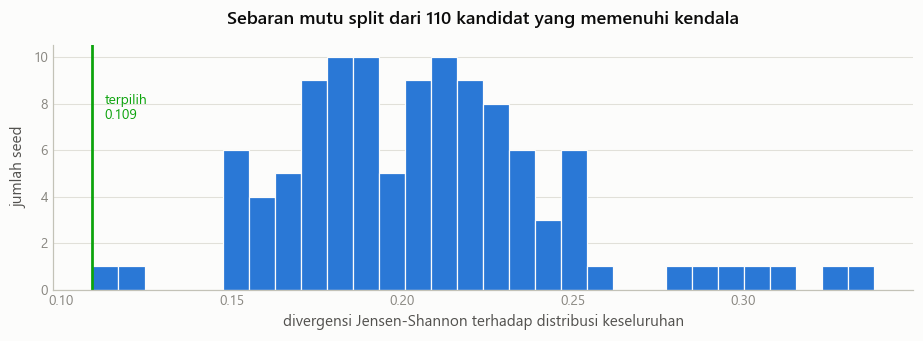

In [5]:
def js_divergence(p, q, eps=1e-9):
    """Jarak Jensen-Shannon — simetris, terbatas 0..1, aman untuk proporsi."""
    p = np.asarray(p, float) + eps; q = np.asarray(q, float) + eps
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)
    kl = lambda a, b: np.sum(a * np.log2(a / b))
    return float(np.sqrt(0.5 * kl(p, m) + 0.5 * kl(q, m)))

KELAS = sorted(boxes["class_id"].unique())
ref = boxes["class_id"].value_counts().reindex(KELAS, fill_value=0).values

def nilai_split(assign):
    """Kembalikan (valid, skor). Skor makin kecil makin baik."""
    p = prof.assign(split=prof["pile"].map(assign))
    b = boxes.assign(split=boxes["pile"].map(assign))

    share = p.groupby("split")["n_frame"].sum() / p["n_frame"].sum()
    if not set(share.index) >= {"train", "val", "test"}:
        return False, np.inf
    # proporsi gambar harus dekat target
    if abs(share["train"] - .70) > .06 or min(share["val"], share["test"]) < .10:
        return False, np.inf
    # tiap split wajib punya semua kelas
    tab = b.groupby(["split", "class_id"]).size().unstack(fill_value=0).reindex(
        columns=KELAS, fill_value=0)
    if (tab == 0).any().any():
        return False, np.inf
    # tiap split wajib punya tumpukan murni DAN campuran
    kar = p.groupby(["split", "murni"]).size().unstack(fill_value=0)
    if kar.shape[1] < 2 or (kar == 0).any().any():
        return False, np.inf

    div = max(js_divergence(tab.loc[s].values, ref) for s in ["val", "test"])
    return True, div

hasil = []
for seed in range(300):
    a = split_per_tumpukan(prof, seed=seed)
    okz, skor = nilai_split(a)
    if okz:
        hasil.append((skor, seed, a))
hasil.sort(key=lambda t: t[0])

print(f"Seed diuji        : 300")
print(f"Memenuhi kendala  : {len(hasil)}")
print(f"Divergensi terbaik: {hasil[0][0]:.4f}  (seed {hasil[0][1]})")
print(f"Divergensi seed 42: "
      f"{[s for s, sd, _ in hasil if sd == 42][0]:.4f}"
      if any(sd == 42 for _, sd, _ in hasil) else "seed 42 tidak memenuhi kendala")

fig, ax = plt.subplots(figsize=(8.5, 3.2))
sk = [s for s, _, _ in hasil]
ax.hist(sk, bins=30, color=vs.PRIMARY, edgecolor=vs.SURFACE, linewidth=0.8)
ax.axvline(hasil[0][0], color=vs.STATUS["good"], linewidth=1.8)
ax.annotate(f"terpilih\n{hasil[0][0]:.3f}", (hasil[0][0], ax.get_ylim()[1]*0.7),
            xytext=(8, 0), textcoords="offset points", fontsize=9,
            color=vs.STATUS["good"])
ax.set_xlabel("divergensi Jensen-Shannon terhadap distribusi keseluruhan")
ax.set_ylabel("jumlah seed")
ax.set_title(f"Sebaran mutu split dari {len(hasil)} kandidat yang memenuhi kendala")
plt.tight_layout(); plt.show()

In [6]:
BEST_SEED = hasil[0][1]
assign = hasil[0][2]
prof["split"] = prof["pile"].map(assign)
imgs["split"] = imgs["pile"].map(assign)
boxes["split"] = boxes["pile"].map(assign)

ringkas = (imgs.groupby("split")
           .agg(gambar=("file", "count"), tumpukan=("pile", "nunique"))
           .reindex(["train", "val", "test"]))
ringkas["% gambar"] = (ringkas.gambar / ringkas.gambar.sum() * 100).round(1)
ringkas["kotak"] = boxes.groupby("split").size().reindex(ringkas.index)
print(f"Seed terpilih: {BEST_SEED}")
ringkas

Seed terpilih: 274


,gambar,tumpukan,% gambar,kotak
split,,,,
train,3037,62,73.0,10290
val,575,15,13.8,2313
test,548,14,13.2,1955


## 4. Verifikasi — tiga hal yang wajib nol atau lengkap

In [7]:
ok = True

# (a) kebocoran tumpukan
sets = {s: set(prof.loc[prof.split == s, "pile"]) for s in ["train", "val", "test"]}
print("(a) Kebocoran tumpukan antar-split")
for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
    n = len(sets[a] & sets[b])
    print(f"    {a:5s} ∩ {b:5s} : {n}")
    ok &= (n == 0)

# (b) kelengkapan kelas
print("\n(b) Kehadiran tiap kelas di tiap split")
pivot = (boxes.groupby(["split", "kelas"]).size().unstack(fill_value=0)
         .reindex(["train", "val", "test"]))
kosong = (pivot == 0).sum().sum()
print(pivot.to_string())
print(f"    sel kosong : {kosong}")
ok &= (kosong == 0)

# (c) kehadiran tumpukan murni DAN campuran di tiap split
print("\n(c) Karakter tumpukan di tiap split")
kar = (prof.groupby(["split", "murni"]).size().unstack(fill_value=0)
       .rename(columns={True: "murni", False: "campuran"})
       .reindex(["train", "val", "test"]))
print(kar.to_string())
ok &= (kar > 0).all().all()

print("\n" + ("VERIFIKASI LULUS — split sah dipakai" if ok
              else "VERIFIKASI GAGAL — periksa kembali"))

(a) Kebocoran tumpukan antar-split
    train ∩ val   : 0
    train ∩ test  : 0
    val   ∩ test  : 0

(b) Kehadiran tiap kelas di tiap split
kelas  Janjang kosong  Kurang masak  TBS abnormal  TBS masak  TBS mentah  Terlalu masak
split                                                                                  
train             625          1856          1827       2411        1771           1800
val                84           365           449        317         608            490
test              148           354           323        245         534            351
    sel kosong : 0

(c) Karakter tumpukan di tiap split
murni  campuran  murni
split                 
train        19     43
val           2     13
test          4     10

VERIFIKASI LULUS — split sah dipakai


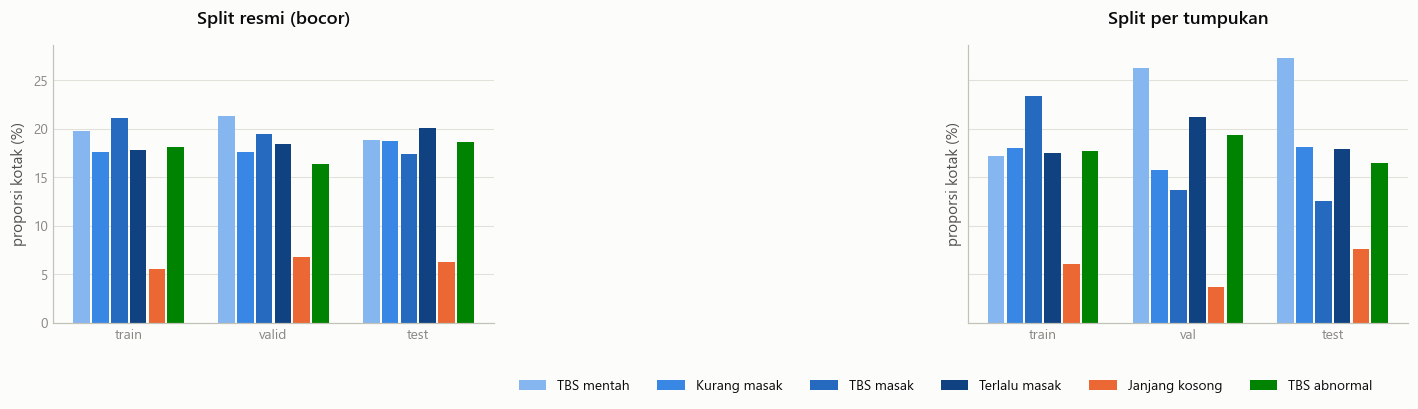

kelas               TBS mentah  Kurang masak  TBS masak  Terlalu masak  \
resmi        train        19.8          17.6       21.1           17.8   
             valid        21.3          17.6       19.4           18.5   
             test         18.9          18.7       17.4           20.1   
per tumpukan train        17.2          18.0       23.4           17.5   
             val          26.3          15.8       13.7           21.2   
             test         27.3          18.1       12.5           18.0   

kelas               Janjang kosong  TBS abnormal  
resmi        train             5.6          18.2  
             valid             6.7          16.4  
             test              6.2          18.7  
per tumpukan train             6.1          17.8  
             val               3.6          19.4  
             test              7.6          16.5

In [8]:
# Perbandingan proporsi kelas: split resmi vs split per tumpukan.
# Yang dicari BUKAN kesamaan sempurna, melainkan tidak adanya kelas yang
# proporsinya runtuh di sisi uji.
a = (boxes.groupby(["split_resmi", "kelas"]).size().unstack(fill_value=0))
a = (a.div(a.sum(axis=1), axis=0) * 100).reindex(["train", "valid", "test"])
b = (boxes.groupby(["split", "kelas"]).size().unstack(fill_value=0))
b = (b.div(b.sum(axis=1), axis=0) * 100).reindex(["train", "val", "test"])

order = [dio.CLASS_NAMES[c] for c in [4, 1, 3, 5, 0, 2]]
a = a[[c for c in order if c in a.columns]]
b = b[[c for c in order if c in b.columns]]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), sharey=True)
for ax, df, judul in [(axes[0], a, "Split resmi (bocor)"),
                      (axes[1], b, "Split per tumpukan")]:
    x = np.arange(len(df.index)); w = 0.13
    for i, kelas in enumerate(df.columns):
        cid = [k for k, v in dio.CLASS_NAMES.items() if v == kelas][0]
        ax.bar(x + (i - 2.5) * w, df[kelas].values, width=w * 0.88,
               color=vs.CLASS_COLORS[cid], label=kelas)
    ax.set_xticks(x); ax.set_xticklabels(df.index)
    ax.set_title(judul); ax.set_ylabel("proporsi kotak (%)")
axes[1].legend(loc="upper center", bbox_to_anchor=(-0.05, -0.16), ncol=6)
plt.tight_layout(); plt.show()

pd.concat({"resmi": a.round(1), "per tumpukan": b.round(1)}, axis=0)

## 5. Masalah tumpukan raksasa

Satu tumpukan menyumbang 421 frame — sekitar 10% seluruh dataset. Frame-frame
itu berasal dari satu adegan yang sama, jadi informasi tambahannya kecil
sementara pengaruhnya pada bobot pelatihan besar.

Di sini diuji efek **pembatasan jumlah frame per tumpukan**: berapa banyak data
yang hilang, dan apakah keseimbangan kelas terganggu.

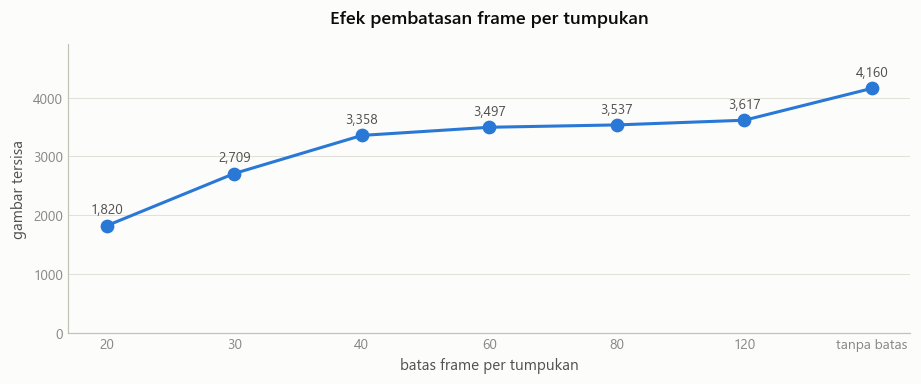

,cap,gambar,% dari penuh,kotak,kelas terkecil %,rentang kelas %
0,20,1820,43.8,6562,4.57,17.8
1,30,2709,65.1,9790,4.57,17.8
2,40,3358,80.7,12253,4.64,16.7
3,60,3497,84.1,12819,4.63,16.5
4,80,3537,85.0,12926,4.77,16.3
5,120,3617,86.9,13150,5.00,15.9
6,tanpa batas,4160,100.0,14558,5.89,14.5


In [9]:
def batasi(imgs_df, cap, seed=SEED):
    return (imgs_df.groupby("pile", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), cap), random_state=seed)))

caps = [20, 30, 40, 60, 80, 120, 10**6]
rows = []
for cap in caps:
    sub = batasi(imgs, cap)
    kb = boxes[boxes.file.isin(set(sub.file))]
    prop = kb["kelas"].value_counts(normalize=True) * 100
    rows.append({
        "cap": "tanpa batas" if cap > 1000 else cap,
        "gambar": len(sub),
        "% dari penuh": round(len(sub) / len(imgs) * 100, 1),
        "kotak": len(kb),
        "kelas terkecil %": round(prop.min(), 2),
        "rentang kelas %": round(prop.max() - prop.min(), 1),
    })
tab = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
xs = list(range(len(tab)))
ax.plot(xs, tab["gambar"], marker="o", color=vs.PRIMARY)
for x, y in zip(xs, tab["gambar"]):
    ax.annotate(f"{y:,}", (x, y), xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9, color=vs.INK_SECONDARY)
ax.set_xticks(xs); ax.set_xticklabels(tab["cap"].astype(str))
ax.set_xlabel("batas frame per tumpukan"); ax.set_ylabel("gambar tersisa")
ax.set_title("Efek pembatasan frame per tumpukan")
ax.set_ylim(0, tab["gambar"].max() * 1.18)
plt.tight_layout(); plt.show()

tab

> **Keputusan.** Pembatasan tidak diterapkan pada split utama — algoritma
> pembagian sudah sadar bobot frame, sehingga tumpukan raksasa tidak lagi
> merusak proporsi antar-split. Pembatasan disimpan sebagai opsi kalau nanti
> waktu latih jadi kendala; tabel di atas menunjukkan biayanya secara eksplisit.

## 6. Menyimpan manifes

Tiga keluaran:

- `split_per_tumpukan.csv` — pemetaan tumpukan → split, dengan karakternya
- `manifest_gambar.csv` — satu baris per gambar, lengkap dengan split baru
- `pile_murni.csv` — daftar tumpukan murni, dipakai untuk evaluasi terpisah
  terhadap risiko jalan pintas

In [10]:
prof_out = prof[["pile", "group", "split", "n_frame", "n_box",
                 "n_kelas_kematangan", "dominasi", "murni"]].sort_values(
                 ["split", "group", "pile"])
prof_out.to_csv(OUT / "split_per_tumpukan.csv", index=False)

man = imgs[["file", "path", "pile", "group", "frame", "n_boxes",
            "split_resmi", "split"]].copy()
man = man.merge(prof[["pile", "murni"]], on="pile", how="left")
man.to_csv(OUT / "manifest_gambar.csv", index=False)

prof_out[prof_out.murni].to_csv(OUT / "pile_murni.csv", index=False)

for s in ["train", "val", "test"]:
    paths = man.loc[man.split == s, "path"].tolist()
    (OUT / f"{s}.txt").write_text("\n".join(paths), encoding="utf-8")

print("Tersimpan di", OUT)
for f in sorted(OUT.glob("*")):
    if f.is_file():
        print(f"  {f.name:28s} {f.stat().st_size/1024:8.1f} KB")

Tersimpan di D:\LOMBA\COMPFEST\neraca-minyak\data\interim
  .gitkeep                          0.0 KB
  manifest_gambar.csv             997.9 KB
  pile_murni.csv                    3.3 KB
  split_per_tumpukan.csv            4.5 KB
  test.txt                         71.7 KB
  train.txt                       399.8 KB
  val.txt                          75.3 KB


## Kesimpulan

### Kebocoran split resmi, dikuantifikasi
Bukan sekadar "tumpukan yang sama muncul di dua sisi". **88,7% gambar uji punya
frame bersebelahan langsung di sisi latih**, dengan median jarak frame **1**.
Sisi uji berisi momen yang praktis sama dengan sisi latih, sehingga metrik dari
split resmi mengukur hafalan, bukan generalisasi.

### Split pengganti
Pembagian dilakukan pada tingkat tumpukan, distratifikasi menurut kelompok, dan
sadar bobot frame. Karena 66 dari 91 tumpukan hanya berisi satu tingkat
kematangan, memindahkan satu tumpukan memindahkan seluruh kelasnya — sehingga
keseimbangan kelas sempurna **tidak mungkin dicapai secara struktural**.

Yang dilakukan sebagai gantinya: menjalankan algoritma pada 300 seed, menyaring
yang memenuhi seluruh kendala, lalu memilih divergensi Jensen-Shannon terkecil.

| | seed pertama (42) | seed terpilih (274) |
|---|---|---|
| Divergensi JS | 0,2189 | **0,1092** |
| `TBS abnormal` di val | 9,9% | **19,4%** |
| `Kurang masak` di val | 31,0% | **15,8%** |

Dari 300 kandidat, 110 memenuhi kendala. Divergensi berhasil ditekan separuh.

### Hasil akhir
```
train : 3.037 gambar (73,0%) | 62 tumpukan (43 murni / 19 campuran) | 10.290 kotak
val   :   575 gambar (13,8%) | 15 tumpukan (13 murni /  2 campuran) |  2.313 kotak
test  :   548 gambar (13,2%) | 14 tumpukan (10 murni /  4 campuran) |  1.955 kotak

kebocoran tumpukan : 0        (sebelumnya 100% dari sisi uji)
kelas hilang       : 0
```

### Keterbatasan yang tersisa — disebut di muka
`TBS mentah` tetap lebih terwakili di sisi uji (27,3%) dibanding latih (17,2%),
dan `TBS masak` sebaliknya (12,5% vs 23,4%). Ini konsekuensi langsung dari
struktur dataset dan tidak dapat dihilangkan dengan pembagian mana pun.
**Metrik per kelas wajib dilaporkan terpisah**, dan rata-rata makro lebih
representatif daripada rata-rata mikro untuk dataset ini.

### Yang dipakai selanjutnya
- `data/interim/manifest_gambar.csv` — satu baris per gambar, dengan split baru
- `data/interim/split_per_tumpukan.csv` — pemetaan tumpukan dan karakternya
- `data/interim/pile_murni.csv` — untuk evaluasi terpisah terhadap risiko jalan pintas
- `train.txt` / `val.txt` / `test.txt` — daftar path siap pakai

Seluruh eksperimen berikutnya memakai split ini. Split resmi tetap
dimaterialisasi sebagai **pembanding**, supaya selisih angkanya bisa
dilaporkan sebagai temuan.

In [11]:
print("=" * 70)
print("RINGKASAN SPLIT PER TUMPUKAN")
print("=" * 70)
for s in ["train", "val", "test"]:
    n_i = int((man.split == s).sum())
    n_p = int((prof.split == s).sum())
    n_m = int(((prof.split == s) & prof.murni).sum())
    n_b = int((boxes.split == s).sum())
    print(f"{s:6s} : {n_i:5,} gambar ({n_i/len(man)*100:4.1f}%) | "
          f"{n_p:2d} tumpukan ({n_m} murni / {n_p-n_m} campuran) | {n_b:6,} kotak")
print("-" * 70)
print(f"Kebocoran tumpukan  : 0  (sebelumnya 100% dari sisi uji)")
print(f"Kelas hilang        : 0")
print("=" * 70)

RINGKASAN SPLIT PER TUMPUKAN
train  : 3,037 gambar (73.0%) | 62 tumpukan (43 murni / 19 campuran) | 10,290 kotak
val    :   575 gambar (13.8%) | 15 tumpukan (13 murni / 2 campuran) |  2,313 kotak
test   :   548 gambar (13.2%) | 14 tumpukan (10 murni / 4 campuran) |  1,955 kotak
----------------------------------------------------------------------
Kebocoran tumpukan  : 0  (sebelumnya 100% dari sisi uji)
Kelas hilang        : 0
